<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/10wk-2.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

{{<video https://youtu.be/playlist?list=PLQqh36zP38-wHF4r0RueQXxVsFHEfOHd-&si=1xguin42o0bm6h1T>}}

# 2. Imports

In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt

In [5]:
plt.rcParams['figure.figsize'] = (4.5,3.0)

# 3. 확률적 경사하강법

## A. 경제관념

`-` GPU-RAM은 시스템-RAM보다 비싸다. 왜? (1) 자체가 비쌈 (2) 여러개를 묶어서 쓸 수 없음.

- <https://shop.danawa.com/virtualestimate/?controller=estimateMain&methods=index&marketPlaceSeq=16>
- <https://prod.danawa.com/info/?pcode=21458333>

`-` 아래의 코드를 다시 살펴보자.

```Python
X = torch.randn(100,1).to("cuda:0")
Y = torch.randn(100,1).to("cuda:0")
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1),
).to("cuda:0")
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
t1 = time.time()
for epoch in range(1000):
    # 1
    Yhat = net(X)
    # 2
    loss = loss_fn(Yhat,Y)
    # 3
    loss.backward()
    # 4
    optimizer.step()
    optimizer.zero_grad()
t2 = time.time()
t2-t1
```

- 구조적으로 (1) X,Y가 커지거나 (2) net이 복잡해지면 GPU-RAM을 더 많이 쓸 수 밖에 없다.
- 참고로 "GPU-RAM을 더 많이 쓴다 = 더 비싼 GPU가 필요하다 = 더 돈이 많이 든다"

## B. 뭔가 이상하다.

`-` 뭔가 비합리적인 생각이 든다. 네트워크가 복잡해질때 더 많은 GPU-RAM이 필요하다는건 알겠는데, 데이터에 비례하여 더 많은 GPU-RAM이 필요하다는건 언뜻 이해가 되지 않음.

`-` 아래와 같은 단순한 예제를 생각해보자.

In [15]:
n = 10000
x = torch.linspace(-10,10,n)
eps = torch.randn(n)
y = 2*x + eps

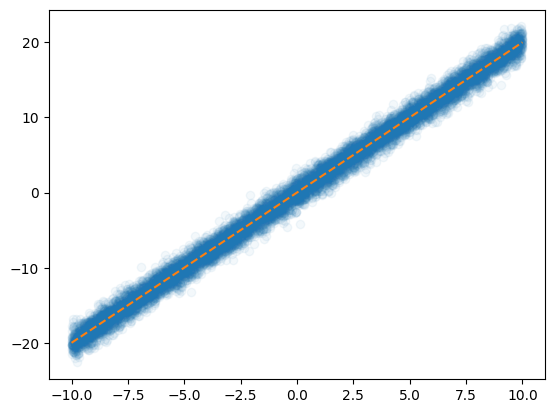

In [16]:
plt.plot(x,y,'o',alpha=0.05)
plt.plot(x,2*x,'--')

`-` 이렇게 단순한 예제도 $n$이 커지는 순간 `X.to("cuda:0")`, `Y.to("cuda:0")` 쓰기 망설여진다.

## C. 굳이 모든 데이터를 GPU-RAM에 올려야하는가?

`-` 모티브: $n$이 충분히 크다면 데이터를 $\frac{1}{10}$만 써서 적합해도 충분할듯?

In [32]:
xm = x[::10]
ym = y[::10]

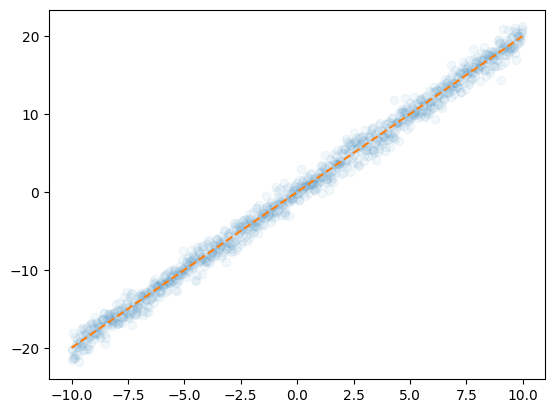

In [33]:
plt.plot(xm,ym,'o',alpha=0.05)
plt.plot(xm,2*xm,'--')

`-` 남은 데이터를 버린다는 의미가 아님. 아래와 같은 해보자는 것임.

- 데이터를 10등분으로 나눈다. 편의상 나누어진 조각을 미니배치1,미니배치2,...,미니배치10이라고 하자.
- 미니배치1의 데이터와 net의 모든 파라메터들을 GPU-RAM에 올린다.
- 그리고 Step1-4를 수행한다. (즉 "미니배치1"을 full-data라고 상상하고 Step1-4를 수행)
- 미니배치1의 데이터를 GPU-RAM에서 내리고 미니배치2의 데이터를 GPU-RAM에 올린다. (단, 여기에서 net의 파라메터들은 계속 GPU-RAM에 올려둠)
- 그리고 Step1-4를 수행한다. (즉 "미니배치2"를 full-data라고 상상하고 Step1-4를 수행)
- 그다음 미니배치2의 데이터를 GPU-RAM에서 내리고 .... (이걸 무한반복)

> 이러면 되는거 아니야?? --> 대충 맞아요

`-` 사소한 문제: 데이터의 숫자가 99개라고 치면 10등분을 했을때 한쪽의 미니배치에는 데이터가 9개만 들어가게 되어있음. (다른건 10개씩인데!!)

`-` 알고리즘을 좀 더 다듬어서..

0. net의 모든 파라메터는 GPU-RAM에 올린다.
1. 데이터 $n$개중에서 $m$개를 임의로 뽑아 "미니배치1"를 만들어 GPU-RAM에 올린다.
2. 미니배치1에 대하여 Step1-4를 수행함.
3. 올려진 미니배치1을 GPU-RAM에서 내리고, 남은 $n-m$개의 데이터에서 다시 $m$개를 임의로 뽑아 "미니배치2"를 만들어 GPU-RAM에 올린다.
4. 미니배치2에 대하여 Step1-4를 수행함.
5. 올려진 미니배치2을 GPU-RAM에서 내리고, 남은 $n-2m$개의 데이터에서 다시 $m$개를 임의로 뽑아 "미니배치3"를 만들어 GPU-RAM에 올린다.
6. 위의 과정을 더 이상 남겨진 데이터가 없을때까지 반복한다.
7. 더이상 남겨진 데이터가 없으면 다시 1로 돌아간다.
8. 반복

`# 예시` -- 5개의 데이터가 있고, 2개씩 GPU에 올린다고 가정. (즉 $n=5$, $m=2$)

0. 모든 파라메터를 GPU에 올림
1. 미니배치를 다음과 같이 구성: (1,3), (2,5), (4)
2. 각 미니배치에 대하여 Step1-4를 수행 // 즉 Step1-4를 3번 수행
3. 미니배치를 다음과 같이 구성: (2,5), (1,4), (3)
4. 각 미니배치에 대하여 Step1-4를 수행 // 즉 Step1-4를 3번 수행
5. 반복 ....

`#`

`-` 용어정리:

1. 이러한 방식을 **확률적 경사하강법**이라고 부른다. (우리가 지금까지 쓴 방식은 그냥 경사하강법)
2. 전체 데이터셋을 한번 통과하는 단위를 **에폭(epoch)**이라고 한다.
3. 전체 학습 데이터셋을 다 쓰지 않고, 일부 샘프들의 묶음 단위로 잘라 사용할 때 그 묶음 하나를 **미니배치**라고 한다.
4. 하나의 미니배치에 안에 들어있는 샘플의 개수 $m$을 **미니배치의 크기**라고 한다.

`-` 코드형태의 슈도알고리즘

```Python
X = ...
Y = ...
net = ...
loss_fn = ...
optimizer = ...
#---#
net.to("cuda:0")
for epoch in range(10):
    --매번 (Xm,Ym)을 뽑고 더 이상 뽑을 미니배치가 없을때까지 아래의 과정을 반복--
        Xm = Xm.to("cuda:0")
        Ym = Ym.to("cuda:0")
        # step 1
        Ymhat = net(Xm)
        # step 2
        loss = loss_fn(Ymhat,Ym)
        # step 3
        loss.backward()
        # step 4
        optimizer.step()
        optimizer.zero_grad()
    # 더 이상 뽑을 미니배치가 없는 경우 한 세트가 끝남. <-- 우리는 이걸 한 에폭이 끝났다 라고 부름
```

> 사족: 사실 꼭 돈때문에 SGD를 쓰는건 아님. SGD는 GD에 비하여 나름 다른 장점도 있음.

## D. Dataset(`ds`), DataLoader(`dl`)

`-` `Dataset`에 대하여 알아보자.

In [39]:
X = torch.tensor([1,2,3,4,5]).float().reshape(-1,1)
Y = torch.tensor([1,1,1,0,0]).float().reshape(-1,1)
X,Y

(tensor([[1.],
         [2.],
         [3.],
         [4.],
         [5.]]),
 tensor([[1.],
         [1.],
         [1.],
         [0.],
         [0.]]))

In [44]:
ds = torch.utils.data.TensorDataset(X,Y)
ds[-1]

(tensor([5.]), tensor([0.]))

In [53]:
for Xi,Yi in ds:
    print(Xi,Yi)

tensor([1.]) tensor([1.])
tensor([2.]) tensor([1.])
tensor([3.]) tensor([1.])
tensor([4.]) tensor([0.])
tensor([5.]) tensor([0.])


`-` `DataLoader`에 대하여 알아보자.

In [79]:
dl = torch.utils.data.DataLoader(ds,batch_size=2,shuffle=True)
# dl[0] # 이건 실행안됨

In [87]:
for Xm,Ym in dl:
    print(Xm,Ym)

tensor([[1.],
        [3.]]) tensor([[1.],
        [1.]])
tensor([[4.],
        [5.]]) tensor([[0.],
        [0.]])
tensor([[2.]]) tensor([[1.]])


*실전에서는 아래와 같은 느낌으로 사용가능함*

In [89]:
for epoch in range(5):
    for Xm,Ym in dl:
        print(Xm) # 편의상 Xm만 출력. Ym은 출력생략
    print("---에폭끝남---")

tensor([[5.],
        [1.]])
tensor([[3.],
        [4.]])
tensor([[2.]])
---에폭끝남---
tensor([[3.],
        [5.]])
tensor([[2.],
        [1.]])
tensor([[4.]])
---에폭끝남---
tensor([[5.],
        [3.]])
tensor([[1.],
        [4.]])
tensor([[2.]])
---에폭끝남---
tensor([[1.],
        [5.]])
tensor([[3.],
        [2.]])
tensor([[4.]])
---에폭끝남---
tensor([[4.],
        [3.]])
tensor([[5.],
        [2.]])
tensor([[1.]])
---에폭끝남---


## E. `ds`, `dl`을 이용하여 MNIST 데이터 적합

`-` 목표: 확률적경사하강법과 경사하강법의 성능을 "동일" 업데이트횟수를 기준으로 비교해보자.

### `#` GPU X, mini-batch X

`-` 데이터준비

In [90]:
## 데이터준비
train_dataset = torchvision.datasets.MNIST(root='./data',train=True,download=True)
test_dataset = torchvision.datasets.MNIST(root='./data',train=False,download=True)
to_tensor = torchvision.transforms.ToTensor()
X3 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==3],axis=0).reshape(-1,28*28)
X7 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==7],axis=0).reshape(-1,28*28)
XX3 = torch.stack([to_tensor(XXi) for XXi, yyi in test_dataset if yyi==3],axis=0).reshape(-1,28*28)
XX7 = torch.stack([to_tensor(XXi) for XXi, yyi in test_dataset if yyi==7],axis=0).reshape(-1,28*28)
X = torch.concat([X3,X7],axis=0)
Y = torch.tensor([0]*6131 + [1]*6265).reshape(-1,1).float() # 숫자3이면 Yi=0, 숫자7이면 Yi=1로 생각하자.
XX = torch.concat([XX3,XX7],axis=0)
YY = torch.tensor([0]*1010 + [1]*1028).reshape(-1,1).float() # 숫자3이면 Yi=0, 숫자7이면 Yi=1로 생각하자.

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


In [97]:
print(X.shape) # train
print(Y.shape) # train
print(XX.shape) # test
print(YY.shape) # train

torch.Size([12396, 784])
torch.Size([12396, 1])
torch.Size([2038, 784])
torch.Size([2038, 1])


`-` Step1-4를 수행하기 위한 준비

In [107]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,1),
    torch.nn.Sigmoid()
)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.SGD(net.parameters())

`-` 적합: Step1-4

In [108]:
for epoch in range(700):
    # step1
    Yhat = net(X)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

`-` 적합결과를 평가

In [109]:
((net(X) > 0.5) == Y).float().mean() # train acc

tensor(0.9574)

In [110]:
((net(XX) > 0.5) == YY).float().mean() # test acc

tensor(0.9573)

> 참고: 업데이트 700, 에폭 700

### `#` GPU O, mini-batch O

`-` 데이터준비 (위와 같음. 생략)

`-` Step1-4를 수행하기 위한 준비

In [112]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,1),
    torch.nn.Sigmoid()
).to("cuda:0")
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.SGD(net.parameters())
ds = torch.utils.data.TensorDataset(X,Y)
dl = torch.utils.data.DataLoader(ds,batch_size=2048,shuffle=True)

준비가 잘 되었는지 체크

In [117]:
for Xm,Ym in dl: # 7번반복함
    print(Xm.shape,Ym.shape)

torch.Size([2048, 784]) torch.Size([2048, 1])
torch.Size([2048, 784]) torch.Size([2048, 1])
torch.Size([2048, 784]) torch.Size([2048, 1])
torch.Size([2048, 784]) torch.Size([2048, 1])
torch.Size([2048, 784]) torch.Size([2048, 1])
torch.Size([2048, 784]) torch.Size([2048, 1])
torch.Size([108, 784]) torch.Size([108, 1])


`-` 적합: Step1-4

In [118]:
for epoch in range(100):
    for Xm,Ym in dl: # 7번반복함
        Xm = Xm.to("cuda:0")
        Ym = Ym.to("cuda:0")
        # step1
        Ymhat = net(Xm)
        # step2
        loss = loss_fn(Ymhat,Ym)
        # step3
        loss.backward()
        # step4
        optimizer.step()
        optimizer.zero_grad()

> 참고: 업데이트 700, 에폭 100

`-` 적합결과 평가  

In [120]:
net.to("cpu")

Sequential(
  (0): Linear(in_features=784, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=1, bias=True)
  (3): Sigmoid()
)

In [121]:
((net(X) > 0.5) == Y).float().mean() # train acc

tensor(0.9572)

In [122]:
((net(XX) > 0.5) == YY).float().mean() # test acc

tensor(0.9573)

# 4. 이항분류에 대한 해석

## A. 이항분류

`-` 데이터준비

In [39]:
train_dataset = torchvision.datasets.MNIST(root='./data',train=True,download=True)
to_tensor = torchvision.transforms.ToTensor()
X3 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==3],axis=0).reshape(-1,28*28)
X7 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==7],axis=0).reshape(-1,28*28)
X = torch.concat([X3,X7],axis=0)
Y = torch.tensor([0]*6131 + [1]*6265).reshape(-1,1).float() # 숫자3이면 Yi=0, 숫자7이면 Yi=1로 생각하자.

`-` 적합

In [40]:
torch.manual_seed(43052)
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,1),
#    torch.nn.Sigmoid()
)
sig = torch.nn.Sigmoid()
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(30):
    # step1
    netout = net(X)
    Yhat = sig(netout)
    # step2
    loss = loss_fn(Yhat,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [41]:
((sig(net(X))>0.5) == Y).float().mean()

tensor(0.9773)

In [42]:
net(X)

tensor([[-4.2168],
        [-3.1701],
        [-5.6188],
        ...,
        [ 2.5660],
        [ 1.9952],
        [ 2.9515]], grad_fn=<AddmmBackward0>)

`#` netout(=logit)의 특징

- $netout>0 \Leftrightarrow sig(netout) > 0.5$
- $netout<0 \Leftrightarrow sig(netout) < 0.5$

In [43]:
((net(X)>0) == Y).float().mean() # 사실 이렇게 코드를 짜도 충분함. (심지어 더 좋은듯. 계산을 덜 하잖아요?)

tensor(0.9773)

`#`

`-` 위의코드는 아래의 코드와 같은 코드임

In [44]:
torch.manual_seed(43052)
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,1),
)
#sig = torch.nn.Sigmoid()
#loss_fn = torch.nn.BCELoss()
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(30):
    # step1
    netout = net(X)
    # step2
    loss = loss_fn(netout,Y)
    # step3
    loss.backward()
    # step4
    optimizer.step()
    optimizer.zero_grad()

In [45]:
((net(X)>0) == Y).float().mean() # 사실 이렇게 코드를 짜도 충분함. (심지어 더 좋은듯. 계산을 덜 하잖아요?)

tensor(0.9773)

## B. 해석과 의미부여

`# 예제1`

In [46]:
sig(net(X))

tensor([[0.0145],
        [0.0403],
        [0.0036],
        ...,
        [0.9286],
        [0.8803],
        [0.9503]], grad_fn=<SigmoidBackward0>)

이 숫자들을 우리는 y=1일 확률이라고 해석했다. y=0일 확률도 같이 나란히 보고싶다면?

(풀이1)

In [47]:
1-sig(net(X)) # y=0 일 확률

tensor([[0.9855],
        [0.9597],
        [0.9964],
        ...,
        [0.0714],
        [0.1197],
        [0.0497]], grad_fn=<RsubBackward1>)

In [48]:
torch.concat([1-sig(net(X)), sig(net(X))],axis=1)

tensor([[0.9855, 0.0145],
        [0.9597, 0.0403],
        [0.9964, 0.0036],
        ...,
        [0.0714, 0.9286],
        [0.1197, 0.8803],
        [0.0497, 0.9503]], grad_fn=<CatBackward0>)

(풀이2)

In [55]:
Logits = torch.concat([torch.zeros(12396,1), net(X)],axis=1)
Logits

tensor([[ 0.0000, -4.2168],
        [ 0.0000, -3.1701],
        [ 0.0000, -5.6188],
        ...,
        [ 0.0000,  2.5660],
        [ 0.0000,  1.9952],
        [ 0.0000,  2.9515]], grad_fn=<CatBackward0>)

In [64]:
torch.exp(Logits) / torch.exp(Logits).sum(axis=1).reshape(12396,1)

tensor([[0.9855, 0.0145],
        [0.9597, 0.0403],
        [0.9964, 0.0036],
        ...,
        [0.0714, 0.9286],
        [0.1197, 0.8803],
        [0.0497, 0.9503]], grad_fn=<DivBackward0>)

(풀이3)

In [71]:
Logits = torch.concat([torch.zeros(12396,1), net(X)],axis=1)
Logits.softmax(axis=1)

tensor([[0.9855, 0.0145],
        [0.9597, 0.0403],
        [0.9964, 0.0036],
        ...,
        [0.0714, 0.9286],
        [0.1197, 0.8803],
        [0.0497, 0.9503]], grad_fn=<SoftmaxBackward0>)

> $\text{softmax}([x_1,x_2]) = [\frac{e^{x_1}}{e^{x_1}+e^{x_2}}, \frac{e^{x_2}}{e^{x_1}+e^{x_2}}]$

`#`

`# 예제2`

아래의 결과를 해석하여 보자.

In [73]:
net(X) # logit

tensor([[-4.2168],
        [-3.1701],
        [-5.6188],
        ...,
        [ 2.5660],
        [ 1.9952],
        [ 2.9515]], grad_fn=<AddmmBackward0>)

- net(X)의 값이 음수 = 1일 확률이 작다 = 0을 확률이 크다
- net(X)의 값이 양수 = 1일 확률이 크다 = 0을 확률이 작다

여기에서 net(X)의 값은 y=1일 근거를 수치화한것으로 볼 수 있다.

- 이 숫자가 클수록 y=1이라고 예측하는게 좋으며,
- 이 숫자가 작을수록 y=0이라고 예측하는게 좋다.
- 그리고 y=1로 예측하는게 좋을지 y=0으로 예측하는게 좋을지 판단하는 기준이 되는 숫자는 0이다. (즉 이 숫자가 양수면 1로, 음수면 0으로 예측)

net(X)의 값 왼쪽에 0이라는 새로운 컬럼을 추가한 아래와 같은 매트릭스에서도 이러한 숫자들의 해석이 유효할까??

In [76]:
Logits = torch.concat([torch.zeros(12396,1), net(X)],axis=1)
Logits

tensor([[ 0.0000, -4.2168],
        [ 0.0000, -3.1701],
        [ 0.0000, -5.6188],
        ...,
        [ 0.0000,  2.5660],
        [ 0.0000,  1.9952],
        [ 0.0000,  2.9515]], grad_fn=<CatBackward0>)

- 오른쪽열의 숫자를 y=1일 근거로 해석하자.
- 왼쪽열의 숫자를 y=0일 근거로 해석하자.
- (오른쪽의 숫자 > 왼쪽의 숫자) $\Leftrightarrow$ (오른쪽의 숫자 > 0) $\Leftrightarrow$ (y=1일 근거가 y=0일 근거보다 더 크다) // y=1로 예측하는게 더 좋음
- (오른쪽의 숫자 < 왼쪽의 숫자) $\Leftrightarrow$ (오른쪽의 숫자 < 0) $\Leftrightarrow$ (y=1일 근거가 y=0일 근거보다 더 작다) // y=0로 예측하는게 더 좋음

그렇다면 softmax함수는 근거를 확률로 변환하는 함수라고 해석할 수 있다.

In [78]:
Logits.softmax(axis=1)

tensor([[0.9855, 0.0145],
        [0.9597, 0.0403],
        [0.9964, 0.0036],
        ...,
        [0.0714, 0.9286],
        [0.1197, 0.8803],
        [0.0497, 0.9503]], grad_fn=<SoftmaxBackward0>)

동일한 논리로 sigmoid역시 근거를 확률로 변환하는 함수라고 해석할 수 있다.

In [81]:
Logit = net(X)
sig(Logit)

tensor([[0.0145],
        [0.0403],
        [0.0036],
        ...,
        [0.9286],
        [0.8803],
        [0.9503]], grad_fn=<SigmoidBackward0>)

In [82]:
Logit.sigmoid()

tensor([[0.0145],
        [0.0403],
        [0.0036],
        ...,
        [0.9286],
        [0.8803],
        [0.9503]], grad_fn=<SigmoidBackward0>)

`#`

`-` 정리

- logit: 1이 나올 근거를 수치화
- sig: 근거를 확률로 바꾸는 함수
- logits: 0이 나올 근거와 1이 나올 근거를 베터형태로 모아둔것
- softmax: 근거들을 확률들로 바꾸는 함수

`# 예제3` -- 예측값을 얻는 코드의 해석

예측값을 값을 얻는 코드를 해석하여 보자.

*코드1*

In [88]:
Prob = sig(net(X))
Yhat = (Prob > 0.5).float()
Yhat

tensor([[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [1.],
        [1.]])

- 1이 나올 확률이 0.5보다 큰것을 1로 예측하겠다는 논리

*코드2*

In [93]:
Logit = net(X)
Yhat = (Logit > 0).float()
Yhat

tensor([[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [1.],
        [1.]])

- "1이 나올 근거>0"이면 1로 예측하겠다는 논리

*코드3*

In [110]:
Logits = torch.concat([torch.zeros(12396,1), net(X)],axis=1)
Probs = Logits.softmax(axis=1)
Yhat = Probs.argmax(axis=1).reshape(12396,1).float()
Yhat

tensor([[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [1.],
        [1.]])

- 0이 나올 확률과 1이 나올 확률을 비교하여 더 큰쪽으로 예측하겠다는 논리

*코드4*

In [115]:
Logits = torch.concat([torch.zeros(12396,1), net(X)],axis=1)
Yhat = Logits.argmax(axis=1).reshape(12396,1).float()
Yhat

tensor([[0.],
        [0.],
        [0.],
        ...,
        [1.],
        [1.],
        [1.]])

- 0이 나올 근거와 1이 나올 근거를 비교하여 더 큰쪽으로 예측하겠다는 논리

`#`